In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']

from warnings import filterwarnings
filterwarnings('ignore')

import sys
sys.path.append('../')

from utils.analyse_results import *

In [2]:
dirname = '../tests/linkage/'
linkage_gain = load_results_linkage(dirname)
print(linkage_gain)

     TargetID        TargetModel    FeatureSet Run  TPSyn  FPSyn  \
0     ID14086  BayesianNetBins10  Correlations   0    0.8    0.2   
1     ID14086  BayesianNetBins10  Correlations   1    0.4    0.0   
2     ID14086  BayesianNetBins10  Correlations  10    0.6    0.4   
3     ID14086  BayesianNetBins10  Correlations  11    0.4    0.4   
4     ID14086  BayesianNetBins10  Correlations  12    0.2    0.4   
...       ...                ...           ...  ..    ...    ...   
2995  ID31432     SanitiserNHSk5         Naive   5    0.0    0.0   
2996  ID31432     SanitiserNHSk5         Naive   6    0.0    0.0   
2997  ID31432     SanitiserNHSk5         Naive   7    0.0    0.0   
2998  ID31432     SanitiserNHSk5         Naive   8    0.0    0.0   
2999  ID31432     SanitiserNHSk5         Naive   9    1.0    1.0   

      AdvantageSyn  AdvantageRaw  PrivacyGain  
0              0.6             1          0.4  
1              0.4             1          0.6  
2              0.2             1       

In [3]:
dirname = '../tests/inference/'
dpath = '../data/texas'
inference_gain = load_results_inference(dirname, dpath)
print(inference_gain)

     Dataset TargetID SensitiveAttribute Run        TargetModel  \
0      texas  ID14086       LengthOfStay   0  BayesianNetBins10   
1      texas  ID14086       LengthOfStay   0   BayesianNetBins2   
2      texas  ID14086       LengthOfStay   0  BayesianNetBins25   
3      texas  ID14086       LengthOfStay   0   BayesianNetBins5   
4      texas  ID14086       LengthOfStay   0    PrivBayesEps0.1   
...      ...      ...                ...  ..                ...   
1795   texas  ID31432               RACE   9   PrivBayesEps15.0   
1796   texas  ID31432               RACE   9    SanitiserNHSk10   
1797   texas  ID31432               RACE   9     SanitiserNHSk2   
1798   texas  ID31432               RACE   9    SanitiserNHSk25   
1799   texas  ID31432               RACE   9     SanitiserNHSk5   

      ProbCorrectRawIn  ProbCorrectRawOut  AdvantageRaw  ProbCorrectSynIn  \
0        8.269030e-263      8.269030e-263           0.0          0.001051   
1        8.269030e-263      8.269030e-263

In [4]:
dirname = '../tests/utility/'
utility_record, utility_agg = load_results_utility(dirname)
print(utility_record)
print("=" * 80)
print(utility_agg)

   TestRecordID  Accuracy TargetID     Run       TargetModel  \
0       ID71120       0.7      OUT   Run 0  BayesianNetBins2   
1       ID84282       0.3      OUT   Run 0  BayesianNetBins2   
2       ID88763       0.5      OUT   Run 0  BayesianNetBins2   
3       ID79216       0.4      OUT   Run 0  BayesianNetBins2   
4       ID92777       0.2      OUT   Run 0  BayesianNetBins2   
..          ...       ...      ...     ...               ...   
0       ID71120       0.9  ID14086  Run 14               Raw   
1       ID84282       1.0  ID14086  Run 14               Raw   
2       ID88763       0.4  ID14086  Run 14               Raw   
3       ID79216       0.2  ID14086  Run 14               Raw   
4       ID92777       1.0  ID14086  Run 14               Raw   

           PredictionModel       LabelVar Dataset  
0   RandomForestClassifier  RiskMortality   texas  
1   RandomForestClassifier  RiskMortality   texas  
2   RandomForestClassifier  RiskMortality   texas  
3   RandomForestClassif

# Trade-off plot

In [5]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pandas import DataFrame


import re
import numpy as np

# パターン定義: (正規表現, 手法名, パラメータ名)
_MODEL_PATTERNS = [
    (r'^BayesianNetBins(\d+\.?\d*)$',   'BayesianNet',   'bins'),
    (r'^PrivBayesEps(\d+\.?\d*)$',      'PrivBayes',     'eps'),
    (r'^SanitiserNHSk(\d+\.?\d*)$',     'SanitiserNHS',  'k'),
]

def parse_target_model(name: str):
    """
    TargetModel文字列から手法名・パラメータ名・パラメータ値を返す。

    Returns
    -------
    method : str   ('BayesianNet', 'PrivBayes', 'SanitiserNHS', or name itself)
    param  : float (パラメータ値、マッチしなければ nan)
    param_label : str (パラメータの意味、例: 'eps', 'k', 'bins')
    """
    for pattern, method, param_label in _MODEL_PATTERNS:
        m = re.fullmatch(pattern, name)
        if m:
            return method, float(m.group(1)), param_label
    # Raw や未知モデルはそのまま返す
    return name, np.nan, None


def normalize_target_model(val):
    """タプル・リスト・文字列を統一して文字列に変換"""
    if isinstance(val, (tuple, list)):
        val = val[0]  # (BayesianNetBins10,) -> 'BayesianNetBins10'
    if not isinstance(val, str):
        return None
    return val.strip()

def add_method_param(df, model_col='TargetModel'):
    df = df.copy()
    df[model_col] = df[model_col].map(normalize_target_model)
    parsed = df[model_col].map(parse_target_model)
    df['Method']     = parsed.map(lambda x: x[0])
    df['Param']      = parsed.map(lambda x: x[1])
    df['ParamLabel'] = parsed.map(lambda x: x[2])
    return df


def plot_privacy_utility_tradeoff(
    res_linkage: DataFrame,
    res_inference: DataFrame,
    res_utility_agg: DataFrame,
    model_col: str = 'TargetModel',
    pred_model_filter: str = None,   # 例: 'LogisticRegression'  Noneなら全平均
    label_var_filter: str = None,    # 例: 'Income'  Noneなら全平均
    figsize: tuple = (14, 6),
):
    """
    プライバシー vs ユーティリティのトレードオフをプロット。

    Parameters
    ----------
    res_linkage     : load_results_linkage() の戻り値
    res_inference   : load_results_inference() の戻り値
    res_utility_agg : load_results_utility() の resultsAgg
    model_col       : 手法+パラメータが入っているカラム名
    pred_model_filter / label_var_filter : Accuracyを絞り込む場合に指定
    """

    rl = add_method_param(res_linkage)
    ri = add_method_param(res_inference)
    ru = add_method_param(res_utility_agg)

    # ---- 2. プライバシー指標を集約（手法 × パラメータ の平均±std） ----
    pg_link = (
        rl.groupby(['Method', 'Param'])['PrivacyGain']
        .agg(['mean', 'std']).reset_index()
        .rename(columns={'mean': 'PG_link', 'std': 'PG_link_std'})
    )
    pg_inf = (
        ri.groupby(['Method', 'Param'])['PrivacyGain']
        .agg(['mean', 'std']).reset_index()
        .rename(columns={'mean': 'PG_inf', 'std': 'PG_inf_std'})
    )

    # ---- 3. ユーティリティ指標を集約 ----
    ru_sub = ru.copy()
    if pred_model_filter:
        ru_sub = ru_sub[ru_sub['PredictionModel'] == pred_model_filter]
    if label_var_filter:
        ru_sub = ru_sub[ru_sub['LabelVar'] == label_var_filter]

    # OUT split の Accuracy を使う（train/testが分かれている場合）
    if 'Split' in ru_sub.columns:
        ru_sub = ru_sub[ru_sub['Split'] == 'OUT']

    acc = (
        ru_sub.groupby(['Method', 'Param'])['Accuracy']
        .agg(['mean', 'std']).reset_index()
        .rename(columns={'mean': 'Acc', 'std': 'Acc_std'})
    )

    # ---- 4. 結合 ----
    merged = pg_link.merge(pg_inf, on=['Method', 'Param'], how='outer') \
                    .merge(acc,    on=['Method', 'Param'], how='inner')
    merged = merged.sort_values(['Method', 'Param'])

    # ---- 5. プロット ----
    methods = sorted(merged['Method'].unique())
    cmap = cm.get_cmap('tab10', len(methods))
    color_map  = {m: cmap(i) for i, m in enumerate(methods)}
    marker_list = ['o', 's', 'D', '^', 'v', 'P', 'X', '*', 'h', '+']
    marker_map = {m: marker_list[i % len(marker_list)] for i, m in enumerate(methods)}

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=False)
    titles    = ['Privacy Gain (Linkage)', 'Privacy Gain (Inference)']
    pg_cols   = ['PG_link',     'PG_inf']
    pg_e_cols = ['PG_link_std', 'PG_inf_std']

    for ax, title, pg_col, pg_e_col in zip(axes, titles, pg_cols, pg_e_cols):
        for method, grp in merged.groupby('Method'):
            grp = grp.dropna(subset=[pg_col, 'Acc']).sort_values('Param')
            if grp.empty:
                continue

            color  = color_map[method]
            marker = marker_map[method]

            # ① 折線
            ax.plot(
                grp['Acc'], grp[pg_col],
                color=color, linewidth=1.5, linestyle='-', alpha=0.6, zorder=1,
                marker=marker, markersize=7, markerfacecolor=color, 
                markeredgecolor='white', markeredgewidth=0.8,  
            )

            # ③ パラメータ値アノテーション
            _PARAM_SYMBOLS = {
                'BayesianNet':  'bins',
                'PrivBayes':    r'$\varepsilon$',
                'SanitiserNHS': r'$k$',
            }

            for _, row in grp.iterrows():
                if np.isnan(row['Param']):
                    continue
                prefix = _PARAM_SYMBOLS.get(method, '?')
                param_val = int(row['Param']) if row['Param'] == int(row['Param']) else row['Param']
                param_str = f"{prefix}={param_val}"

                ax.annotate(
                    param_str,
                    xy=(row['Acc'], row[pg_col]),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=10, color=color,
                    arrowprops=dict(arrowstyle='-', color=color,
                                   lw=0.8, alpha=0.6),
                    zorder=3,
                )

        ax.axhline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.set_xlabel('Accuracy', fontsize=12)
        ax.set_ylabel('Privacy Gain', fontsize=12)
        ax.set_title(title, fontsize=13)
        ax.tick_params(labelsize=10)


    # ← ここから差し替え（axes[0].get_legend_handles_labels() の部分を削除して）
    from matplotlib.lines import Line2D

    legend_handles = [
        Line2D([0], [0],
               color=color_map[m],
               marker=marker_map[m],
               linewidth=1.5,
               markersize=8,
               label=m)
        for m in methods
    ]

    fig.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.02),
        ncol=min(len(methods), 5),
        fontsize=10,
        title='Method',
        title_fontsize=10,
        framealpha=0.9,
    )

    plt.tight_layout()
    return fig

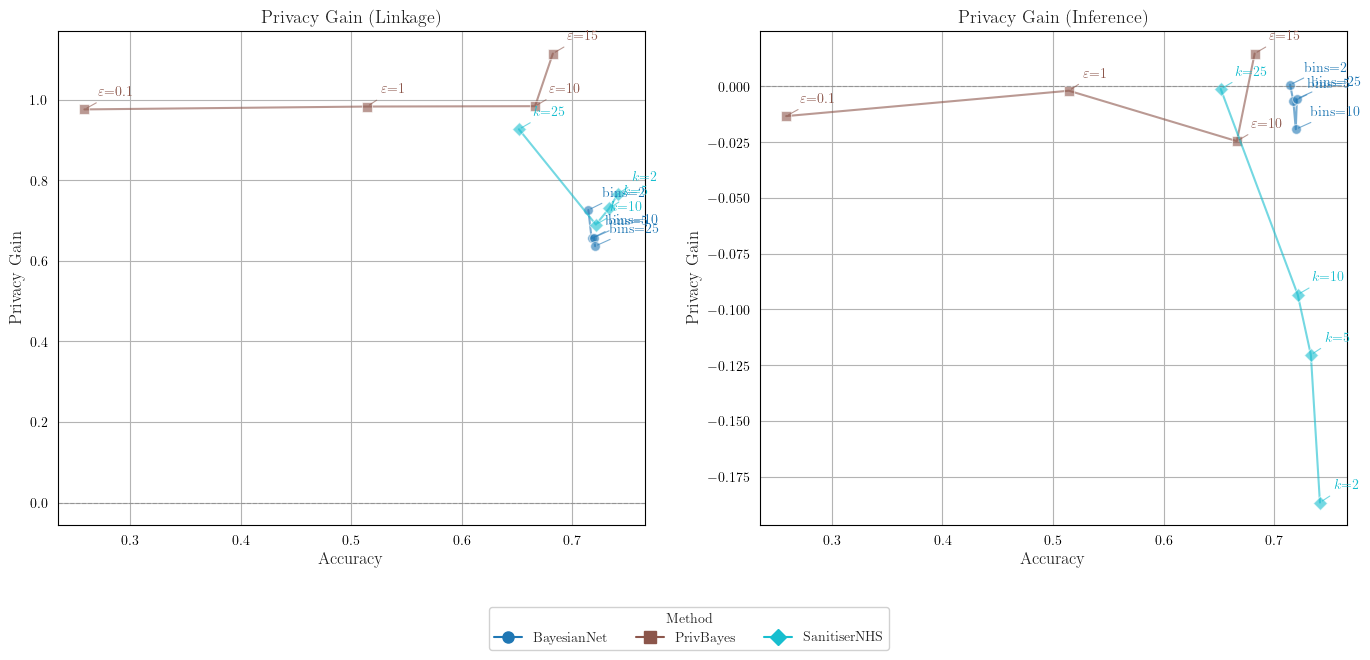

In [6]:
res_link = load_results_linkage('../tests/linkage/')

res_inf  = load_results_inference('../tests/inference/', '../data/texas')
res_tgt, res_agg = load_results_utility('../tests/utility/')

fig = plot_privacy_utility_tradeoff(res_link, res_inf, res_agg)
fig.savefig('tradeoff.pdf', bbox_inches='tight')

In [7]:
print(res_inf)

     Dataset TargetID SensitiveAttribute Run        TargetModel  \
0      texas  ID14086       LengthOfStay   0  BayesianNetBins10   
1      texas  ID14086       LengthOfStay   0   BayesianNetBins2   
2      texas  ID14086       LengthOfStay   0  BayesianNetBins25   
3      texas  ID14086       LengthOfStay   0   BayesianNetBins5   
4      texas  ID14086       LengthOfStay   0    PrivBayesEps0.1   
...      ...      ...                ...  ..                ...   
1795   texas  ID31432               RACE   9   PrivBayesEps15.0   
1796   texas  ID31432               RACE   9    SanitiserNHSk10   
1797   texas  ID31432               RACE   9     SanitiserNHSk2   
1798   texas  ID31432               RACE   9    SanitiserNHSk25   
1799   texas  ID31432               RACE   9     SanitiserNHSk5   

      ProbCorrectRawIn  ProbCorrectRawOut  AdvantageRaw  ProbCorrectSynIn  \
0        8.269030e-263      8.269030e-263           0.0          0.001051   
1        8.269030e-263      8.269030e-263

In [8]:
print(res_tgt)

   TestRecordID  Accuracy TargetID     Run       TargetModel  \
0       ID71120       0.7      OUT   Run 0  BayesianNetBins2   
1       ID84282       0.3      OUT   Run 0  BayesianNetBins2   
2       ID88763       0.5      OUT   Run 0  BayesianNetBins2   
3       ID79216       0.4      OUT   Run 0  BayesianNetBins2   
4       ID92777       0.2      OUT   Run 0  BayesianNetBins2   
..          ...       ...      ...     ...               ...   
0       ID71120       0.9  ID14086  Run 14               Raw   
1       ID84282       1.0  ID14086  Run 14               Raw   
2       ID88763       0.4  ID14086  Run 14               Raw   
3       ID79216       0.2  ID14086  Run 14               Raw   
4       ID92777       1.0  ID14086  Run 14               Raw   

           PredictionModel       LabelVar Dataset  
0   RandomForestClassifier  RiskMortality   texas  
1   RandomForestClassifier  RiskMortality   texas  
2   RandomForestClassifier  RiskMortality   texas  
3   RandomForestClassif

In [9]:
print(res_agg)

   TargetID  Accuracy         PredictionModel       LabelVar  \
0       OUT  0.709984  RandomForestClassifier  RiskMortality   
1   ID26241  0.713988  RandomForestClassifier  RiskMortality   
2   ID31432  0.712542  RandomForestClassifier  RiskMortality   
3   ID27428  0.719202  RandomForestClassifier  RiskMortality   
4   ID29265  0.708996  RandomForestClassifier  RiskMortality   
..      ...       ...                     ...            ...   
85  ID26241  0.741038  RandomForestClassifier  RiskMortality   
86  ID31432  0.741268  RandomForestClassifier  RiskMortality   
87  ID27428  0.740984  RandomForestClassifier  RiskMortality   
88  ID29265  0.741414  RandomForestClassifier  RiskMortality   
89  ID14086  0.741924  RandomForestClassifier  RiskMortality   

         TargetModel Dataset  
0   BayesianNetBins2   texas  
1   BayesianNetBins2   texas  
2   BayesianNetBins2   texas  
3   BayesianNetBins2   texas  
4   BayesianNetBins2   texas  
..               ...     ...  
85            